<a href="https://colab.research.google.com/github/shreyashan-git/undergrad_ml_assignments/blob/main/04_assignment_regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 4: Regularization

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?
2. How does regularization provide a way of exploring the bias-variance trade-off?
3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?
4. How do we typically scale variables for use in regularized regression? Why?
5. How is the penalty $\alpha$ typically selected?
6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?

1. Adding the penalty just keeps the model in check. Instead of chasing a perfect fit with huge coefficients, it forces the model to stay simple and only keep what actually matters.

2. Regularization gives you a knob to control model complexity, as you increase the penalty, you reduce variance but add bias. The goal is to land somewhere in the middle where the model isn’t overfitting but still captures the real signal.

3. Ridge just shrinks everything down, but LASSO actually cuts things out. So Ridge keeps all the variables but makes them smaller, while LASSO picks a subset and zeros out the rest, which makes the model much cleaner.

4. We standardize everything so all variables are on the same scale. Otherwise, the penalty would hit some variables harder just because of their units, not because they actually matter more.

5. You basically test different alpha values and pick the one that gives the best performance on validation data. It’s just tuning the penalty to get the best balance between fit and simplicity.

6. The penalty is just there to shape the model during training. When evaluating it, the only thing to care about is prediction error, so the penalty in the MSE is not inclufed.

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them.
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?
7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, LassoCV, lasso_path
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
df = pd.read_csv('/content/sample_data/cars_hw.csv', encoding = 'latin1')
df['Age'] = 2024 - df['Make_Year']
X = df[['Mileage_Run', 'Age']]
y = df['Price']
poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X)
feature_names = poly.get_feature_names_out(['Mileage_Run', 'Age'])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)



In [ ]:
lr = LinearRegression()
lr.fit(X_scaled, y)
lr_coefs = pd.Series(lr.coef_, index=feature_names)
print(lr_coefs)

Mileage_Run          6.686165e+05
Age                 -1.841941e+05
Mileage_Run^2       -1.494679e+05
Mileage_Run Age     -1.251592e+06
Age^2                2.156399e+05
Mileage_Run^3       -6.514490e+04
Mileage_Run^2 Age    2.833392e+05
Mileage_Run Age^2    5.280829e+05
Age^3               -1.389370e+05
dtype: float64


2. The interaction term between Mileage_Run and Age is negative.

In [ ]:
alphas = np.logspace(1, 3, 20)
lasso = LassoCV(alphas=alphas, cv=20, max_iter=10000)
lasso.fit(X_scaled, y)
best_alpha = lasso.alpha_
print("Best alpha:", best_alpha)

Best alpha: 483.2930238571752


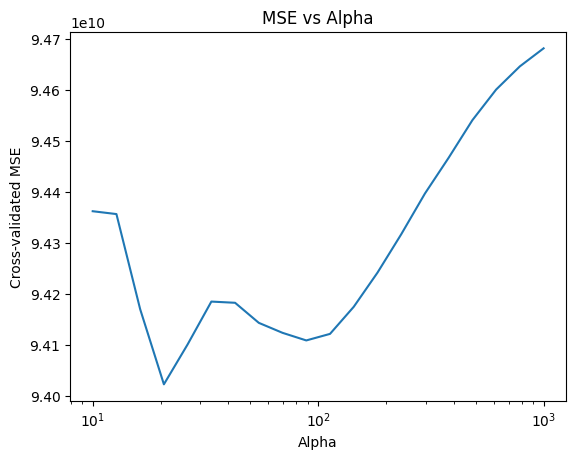

In [ ]:
mse_path = lasso.mse_path_.mean(axis=1)
plt.plot(alphas, mse_path)
plt.xscale('log')
plt.xlabel("Alpha")
plt.ylabel("Cross-validated MSE")
plt.title("MSE vs Alpha")
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 185708452846.75, tolerance: 66748451500.0
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 1496502935991.375, tolerance: 66748451500.0
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 1062651595526.5, tolerance: 66748451500.0
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective 

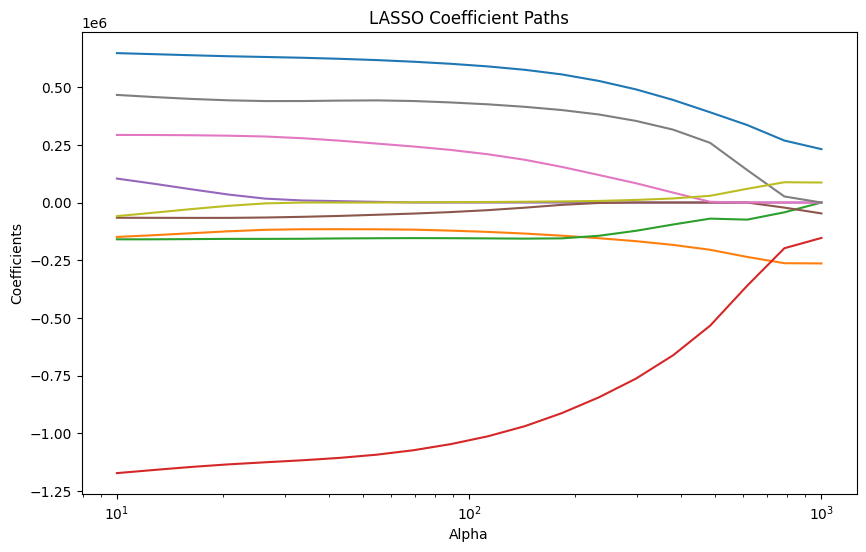

In [ ]:
alphas_lasso, coefs_lasso, _ = lasso_path(X_scaled, y, alphas=alphas)
plt.figure(figsize=(10,6))
for i in range(coefs_lasso.shape[0]):
    plt.plot(alphas_lasso, coefs_lasso[i])
plt.xscale('log')
plt.xlabel("Alpha")
plt.ylabel("Coefficients")
plt.title("LASSO Coefficient Paths")
plt.show()

6. LASSO basically keeps the main effects and the key interaction (Mileage_Run, Age), and gets rid of most of the higher-order noise. About half the features are pushed to zero.

7. LASSO shrinks everything toward zero, so no coefficients get bigger, and while the main effects keep their sign, a few smaller higher-order terms may flip the sign.

**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, LassoCV, lasso_path
import matplotlib.pyplot as plt
df = pd.read_csv('/content/sample_data/heart_failure_clinical_records_dataset.csv', encoding = 'latin1')
y = df['DEATH_EVENT']
cont_vars = ['age', 'ejection_fraction', 'serum_creatinine']
poly = PolynomialFeatures(degree=3, include_bias=False)
X_cont_poly = poly.fit_transform(df[cont_vars])
cont_feature_names = poly.get_feature_names_out(cont_vars)
scaler = StandardScaler()
X_cont_scaled = scaler.fit_transform(X_cont_poly)
dummy_vars = ['anaemia', 'diabetes', 'high_blood_pressure', 'smoking']
poly_dummy = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_dummy_interact = poly_dummy.fit_transform(df[dummy_vars])
dummy_feature_names = poly_dummy.get_feature_names_out(dummy_vars)

In [ ]:
X = np.hstack([X_cont_scaled, X_dummy_interact])
feature_names = list(cont_feature_names) + list(dummy_feature_names)
lr = LinearRegression()
lr.fit(X, y)
lr_coefs = pd.Series(lr.coef_, index=feature_names)
print(lr_coefs.sort_values())

age^2                                    -3.678654
serum_creatinine^2                       -2.647041
ejection_fraction                        -2.192494
age ejection_fraction serum_creatinine   -1.577665
ejection_fraction^2 serum_creatinine     -1.270043
ejection_fraction^3                      -1.250341
serum_creatinine                         -0.853588
age^2 serum_creatinine                   -0.697522
age ejection_fraction                    -0.600918
smoking                                  -0.102687
age ejection_fraction^2                  -0.081206
diabetes                                 -0.070705
anaemia high_blood_pressure              -0.027251
high_blood_pressure                      -0.007934
anaemia                                   0.008093
anaemia diabetes                          0.026159
anaemia smoking                           0.064908
serum_creatinine^3                        0.072156
high_blood_pressure smoking               0.101455
diabetes high_blood_pressure   

2. Yes, some of the signs look off, like serum_creatinine and smoking showing up negative, which doesn’t really make sense clinically. But that is probably because once you throw in all the polynomial and interaction terms, the model isn’t interpreting these variables on their own anymore. The effect gets spread across multiple terms. So a variable can look negative by itself, but when you factor in its squared terms or interactions, the overall relationship can still align with what we expect.

In [ ]:
alphas = np.logspace(-5, 5, 30)
lasso = LassoCV(alphas=alphas, cv=20, max_iter=10000)
lasso.fit(X, y)
print("Best alpha:", lasso.alpha_)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 1.1655699255817744, tolerance: 0.005832394366197185
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 3.019422437013997, tolerance: 0.005832394366197185
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 7.954870463666694, tolerance: 0.005832394366197185
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: Conv

Best alpha: 0.005736152510448681


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 5.1181730205264415, tolerance: 0.006366315789473686
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 9.150914196795643, tolerance: 0.006366315789473686
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 12.667061274978789, tolerance: 0.006366315789473686
  model = cd_fast.enet_coordinate_descent_gram(


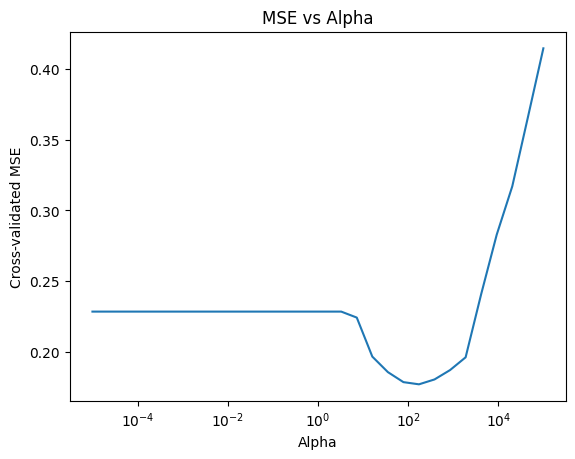

In [ ]:
mse_path = lasso.mse_path_.mean(axis=1)
plt.plot(alphas, mse_path)
plt.xscale('log')
plt.xlabel("Alpha")
plt.ylabel("Cross-validated MSE")
plt.title("MSE vs Alpha")
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.1335358515879932, tolerance: 0.009600000000000001
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.012804029935630012, tolerance: 0.009600000000000001
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 5.358315720381807, tolerance: 0.009600000000000001
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: C

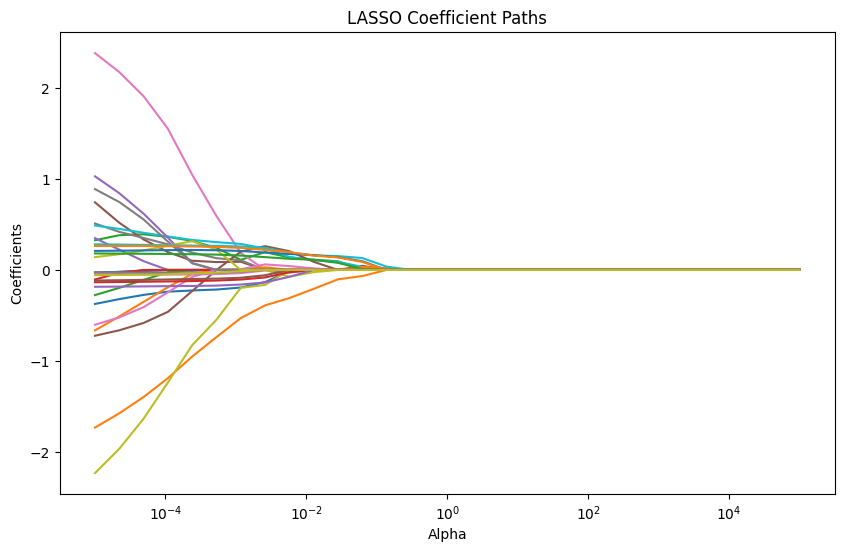

In [ ]:
alphas_lasso, coefs_lasso, _ = lasso_path(X, y, alphas=alphas)
plt.figure(figsize=(10,6))
for i in range(coefs_lasso.shape[0]):
    plt.plot(alphas_lasso, coefs_lasso[i])
plt.xscale('log')
plt.xlabel("Alpha")
plt.ylabel("Coefficients")
plt.title("LASSO Coefficient Paths")
plt.show()

7. LASSO basically wipes out most of the higher-order noise and keeps only the core variables. Around 70–85% of the coefficients go to zero. Nothing increases in magnitude, mostly everything shrinks. Also, while a few small terms flip sign, the main variables stay consistent. Overall, LASSO makes more sense because it reduces variance and gives a cleaner, more stable model compared to the overfit linear regression.

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?
2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.
3. How does increasing $\alpha$ change the slope coefficient?
4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?

1. You’re just taking the usual MSE with the centered variables and adding a penalty on
𝑏1^2, so the model balances fit and keeping the coefficient small.

2. After solving, b0 just drops out to 0, while b1 ooks like the usual formula, except the denominator has that +α term, which shrinks the coefficient.

3. As alpha increases, you’re basically penalizing the slope more, so it gets pushed closer and closer to zero.

4. The issue with LASSO is you can’t take a clean derivative at zero, so you have to think piecewise. Also, if the relationship between x and y isn’t strong enough, the penalty just kills the coefficient completely and that is when it is optimal to set b1 to zero.